# Оценка моделей, ансамбли и анализ

Ноутбук загружает признаки и Optuna-модели, оценивает их на тестовой выборке, выполняет кросс-валидацию, оптимизацию порога, строит soft voting ансамбль, анализирует ошибки и feature importance.

## Импорты и загрузка данных

In [1]:
import os
import sys
import pickle
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import load_npz
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
)
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB

try:
    _project_root = os.path.dirname(os.path.dirname(os.path.dirname(os.path.abspath(__file__))))
except NameError:
    _cwd = os.getcwd()
    _project_root = _cwd
    while _project_root != '/' and not os.path.isdir(os.path.join(_project_root, 'src')):
        _project_root = os.path.dirname(_project_root)
if _project_root not in sys.path:
    sys.path.insert(0, _project_root)

from src.models.classical import (
    NUMERICAL_COLUMNS,
    predict_message,
    save_models,
)
from src.evaluation.metrics import optimize_threshold
from src.config import PROCESSED_DIR, MODELS_DIR, INTERIM_DIR

import lightgbm
import nltk

nltk.download('stopwords', quiet=True)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings(
    'ignore',
    message='X does not have valid feature names',
    category=UserWarning,
    module='sklearn.utils.validation',
)

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

CLASSIC_INTERIM_DIR = INTERIM_DIR / 'classic'
CLASSIC_INTERIM_DIR.mkdir(parents=True, exist_ok=True)
CLASSIC_MODELS_DIR = MODELS_DIR / 'classic'
CLASSIC_MODELS_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
X_train = load_npz(CLASSIC_INTERIM_DIR / 'features_train.npz')
X_train_nc = load_npz(CLASSIC_INTERIM_DIR / 'features_train_nc.npz')
y_train = np.load(CLASSIC_INTERIM_DIR / 'y_train.npy')

X_test = load_npz(CLASSIC_INTERIM_DIR / 'features_test.npz')
X_test_nc = load_npz(CLASSIC_INTERIM_DIR / 'features_test_nc.npz')
y_test = np.load(CLASSIC_INTERIM_DIR / 'y_test.npy')

with open(CLASSIC_INTERIM_DIR / 'base_models.pkl', 'rb') as f:
    base_models = pickle.load(f)

with open(CLASSIC_INTERIM_DIR / 'optuna_models.pkl', 'rb') as f:
    optuna_data = pickle.load(f)
optuna_results = optuna_data['models']

y_test_arr = np.array(y_test)
print(f'Загружено моделей: {len(optuna_results)}')
print(f'Модели: {list(optuna_results.keys())}')

Загружено моделей: 5
Модели: ['lr', 'lgbm', 'svc', 'sgd', 'nb']


Функция для вычисления метрик на тестовой выборке.

In [3]:
def evaluate_on_test(models, X_test, y_test, X_test_nc=None, prefix='base'):
    """Вычисляет метрики для каждой модели на тестовой выборке."""
    results = []
    for name, model in models.items():
        X_eval = X_test_nc if name == 'nb' and X_test_nc is not None else X_test
        y_pred = model.predict(X_eval)
        y_proba = model.predict_proba(X_eval)[:, 1]

        results.append({
            'model': f'{prefix}_{name}',
            'accuracy': float((y_pred == y_test).mean()),
            'precision_spam': float(precision_score(y_test, y_pred, pos_label=1, zero_division=0)),
            'recall_spam': float(recall_score(y_test, y_pred, pos_label=1, zero_division=0)),
            'f1_spam': float(f1_score(y_test, y_pred, pos_label=1, zero_division=0)),
            'f1_macro': float(f1_score(y_test, y_pred, average='macro', zero_division=0)),
            'roc_auc': float(roc_auc_score(y_test, y_proba)),
            'pr_auc': float(average_precision_score(y_test, y_proba)),
        })
    return pd.DataFrame(results)

## Оценка на тестовой выборке

Сравнение базовых моделей и моделей после Optuna.

In [4]:
base_results = evaluate_on_test(base_models, X_test, y_test_arr, X_test_nc, prefix='base')
optuna_results_df = evaluate_on_test(optuna_results, X_test, y_test_arr, X_test_nc, prefix='optuna')
all_results = pd.concat([base_results, optuna_results_df], ignore_index=True)
all_results = all_results.sort_values('f1_macro', ascending=False).reset_index(drop=True)
all_results

,model,accuracy,precision_spam,recall_spam,f1_spam,f1_macro,roc_auc,pr_auc
0,optuna_lr,0.962170,0.975162,0.940461,0.957497,0.961707,0.990108,0.990363
1,base_sgd,0.962025,0.971863,0.943502,0.957473,0.961585,0.992386,0.990148
2,optuna_sgd,0.961855,0.970508,0.944516,0.957335,0.961422,0.993729,0.992113
3,base_svc,0.961904,0.992145,0.923229,0.956447,0.961296,0.987677,0.988769
4,optuna_svc,0.961855,0.992201,0.923069,0.956387,0.961246,0.987929,0.988925
5,base_lr,0.961348,0.974536,0.939234,0.956560,0.960872,0.990908,0.990909
6,base_lgbm,0.953613,0.974719,0.921522,0.947374,0.952951,0.969041,0.977091
7,optuna_lgbm,0.947279,0.971102,0.910745,0.939955,0.946483,0.962029,0.972510
8,optuna_nb,0.927144,0.950716,0.885083,0.916727,0.925985,0.968591,0.971579
9,base_nb,0.921560,0.947870,0.875000,0.909979,0.920240,0.964784,0.968173


## Classification reports

Подробные отчёты классификации для каждой модели после Optuna.

In [5]:
for name, model in optuna_results.items():
    X_eval = X_test_nc if name == 'nb' else X_test
    y_pred = model.predict(X_eval)
    print(f'optuna_{name}')
    print(classification_report(y_test_arr, y_pred, target_names=['Ham', 'Spam']))
    print()

optuna_lr
              precision    recall  f1-score   support

         Ham       0.95      0.98      0.97     22625
        Spam       0.98      0.94      0.96     18744

    accuracy                           0.96     41369
   macro avg       0.96      0.96      0.96     41369
weighted avg       0.96      0.96      0.96     41369


optuna_lgbm
              precision    recall  f1-score   support

         Ham       0.93      0.98      0.95     22625
        Spam       0.97      0.91      0.94     18744

    accuracy                           0.95     41369
   macro avg       0.95      0.94      0.95     41369
weighted avg       0.95      0.95      0.95     41369


optuna_svc
              precision    recall  f1-score   support

         Ham       0.94      0.99      0.97     22625
        Spam       0.99      0.92      0.96     18744

    accuracy                           0.96     41369
   macro avg       0.97      0.96      0.96     41369
weighted avg       0.96      0.96      

## Confusion matrices

Матрицы ошибок для всех моделей после Optuna.

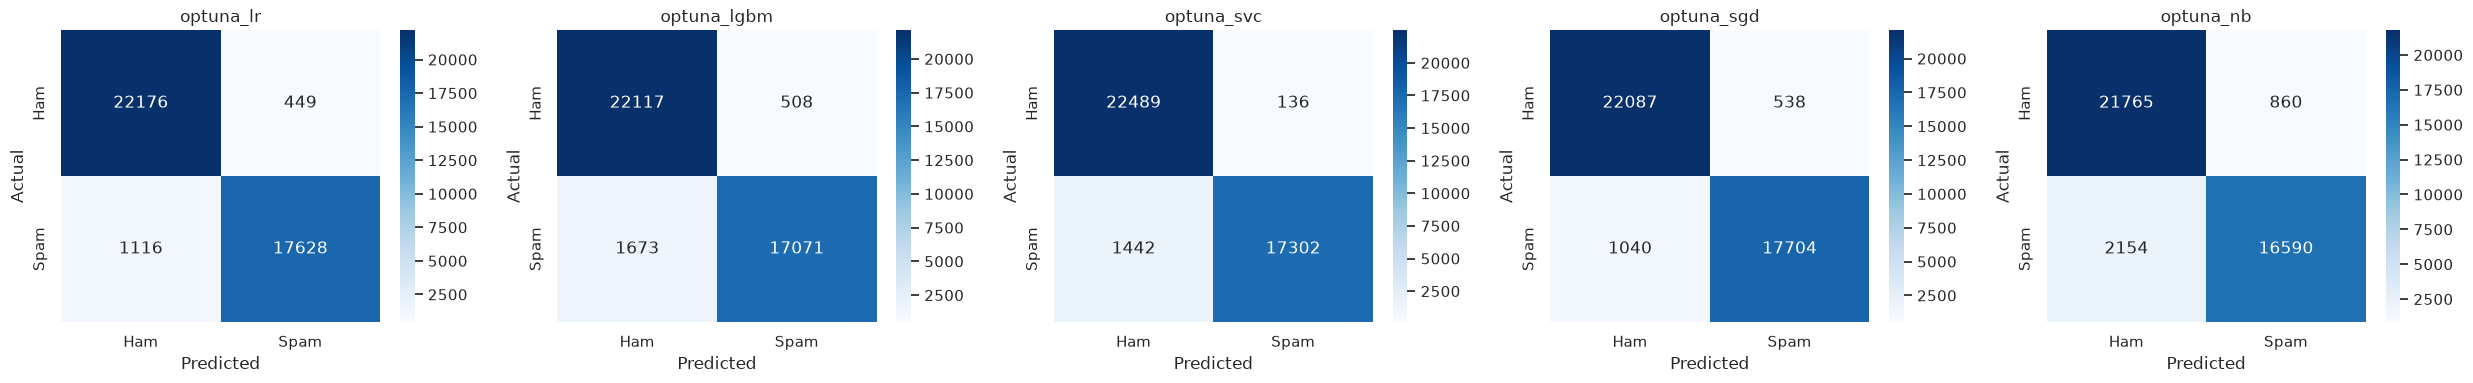

In [6]:
fig, axes = plt.subplots(1, len(optuna_results), figsize=(5 * len(optuna_results), 4))
if len(optuna_results) == 1:
    axes = [axes]

for ax, (name, model) in zip(axes, optuna_results.items()):
    X_eval = X_test_nc if name == 'nb' else X_test
    y_pred = model.predict(X_eval)
    cm = confusion_matrix(y_test_arr, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
    ax.set_title(f'optuna_{name}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()

## Кросс-валидация (3-fold)

Stratified 3-fold CV на обучающей выборке для оценки устойчивости моделей.

In [7]:
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_results = []

for name, model in optuna_results.items():
    X_eval = X_train_nc if name == 'nb' else X_train
    f1_scores = cross_val_score(model, X_eval, y_train, cv=cv3, scoring='f1_macro', n_jobs=-1)
    cv_results.append({
        'model': f'optuna_{name}',
        'f1_macro_mean': float(f1_scores.mean()),
        'f1_macro_std': float(f1_scores.std()),
    })

cv_df = pd.DataFrame(cv_results).sort_values('f1_macro_mean', ascending=False)
cv_df

,model,f1_macro_mean,f1_macro_std
0,optuna_lr,0.961055,0.000382
3,optuna_sgd,0.955421,0.000904
2,optuna_svc,0.950665,0.000087
1,optuna_lgbm,0.937119,0.001185
4,optuna_nb,0.845930,0.000557


## Оптимизация порога классификации

Для каждой модели подбирается порог, максимизирующий Precision при Recall >= 0.90.

In [8]:
TARGET_RECALL = 0.90
threshold_results = []

for name, model in optuna_results.items():
    X_eval = X_test_nc if name == 'nb' else X_test
    y_proba = model.predict_proba(X_eval)[:, 1]
    thr = optimize_threshold(y_test_arr, y_proba, target_recall=TARGET_RECALL)
    threshold_results.append({
        'model': f'optuna_{name}',
        'threshold': thr['threshold'],
        'precision': thr['precision'],
        'recall': thr['recall'],
    })

threshold_df = pd.DataFrame(threshold_results).sort_values('precision', ascending=False)
threshold_df

,model,threshold,precision,recall
0,optuna_lr,0.925469,0.996517,0.900608
2,optuna_svc,0.633252,0.996164,0.900501
3,optuna_sgd,0.785742,0.993523,0.900128
1,optuna_lgbm,0.584347,0.982185,0.900075
4,optuna_nb,0.270776,0.938164,0.900075


## Soft Voting ансамбль

На основе топ-3 моделей по F1-macro строится soft voting ансамбль — усреднение предсказанных вероятностей.

In [9]:
top3_names = cv_df.head(3)['model'].values
top3_keys = [n.replace('optuna_', '') for n in top3_names]
print(f'Топ-3 модели для ансамбля: {top3_keys}')

Топ-3 модели для ансамбля: ['lr', 'sgd', 'svc']


In [10]:
estimators = []
for name in top3_keys:
    model = optuna_results[name]
    estimators.append((name, model))

voting = VotingClassifier(estimators=estimators, voting='soft', n_jobs=1)
voting.fit(X_train, y_train)

print('Soft voting ансамбль обучен')

Soft voting ансамбль обучен


In [11]:
ensemble_models = {'voting': voting}
ensemble_results = evaluate_on_test(ensemble_models, X_test, y_test_arr, prefix='ensemble')
ensemble_results

,model,accuracy,precision_spam,recall_spam,f1_spam,f1_macro,roc_auc,pr_auc
0,ensemble_voting,0.963523,0.981236,0.93742,0.958828,0.963043,0.993211,0.99291


## Итоговая таблица сравнения

Объединение всех результатов: базовые модели, Optuna-модели, ансамбль. Сортировка по F1-macro.

In [12]:
final_results = pd.concat([all_results, ensemble_results], ignore_index=True)
final_results = final_results.sort_values('f1_macro', ascending=False).reset_index(drop=True)
final_results

,model,accuracy,precision_spam,recall_spam,f1_spam,f1_macro,roc_auc,pr_auc
0,ensemble_voting,0.963523,0.981236,0.937420,0.958828,0.963043,0.993211,0.992910
1,optuna_lr,0.962170,0.975162,0.940461,0.957497,0.961707,0.990108,0.990363
2,base_sgd,0.962025,0.971863,0.943502,0.957473,0.961585,0.992386,0.990148
3,optuna_sgd,0.961855,0.970508,0.944516,0.957335,0.961422,0.993729,0.992113
4,base_svc,0.961904,0.992145,0.923229,0.956447,0.961296,0.987677,0.988769
5,optuna_svc,0.961855,0.992201,0.923069,0.956387,0.961246,0.987929,0.988925
6,base_lr,0.961348,0.974536,0.939234,0.956560,0.960872,0.990908,0.990909
7,base_lgbm,0.953613,0.974719,0.921522,0.947374,0.952951,0.969041,0.977091
8,optuna_lgbm,0.947279,0.971102,0.910745,0.939955,0.946483,0.962029,0.972510
9,optuna_nb,0.927144,0.950716,0.885083,0.916727,0.925985,0.968591,0.971579


Визуализация итогового сравнения по ключевым метрикам.

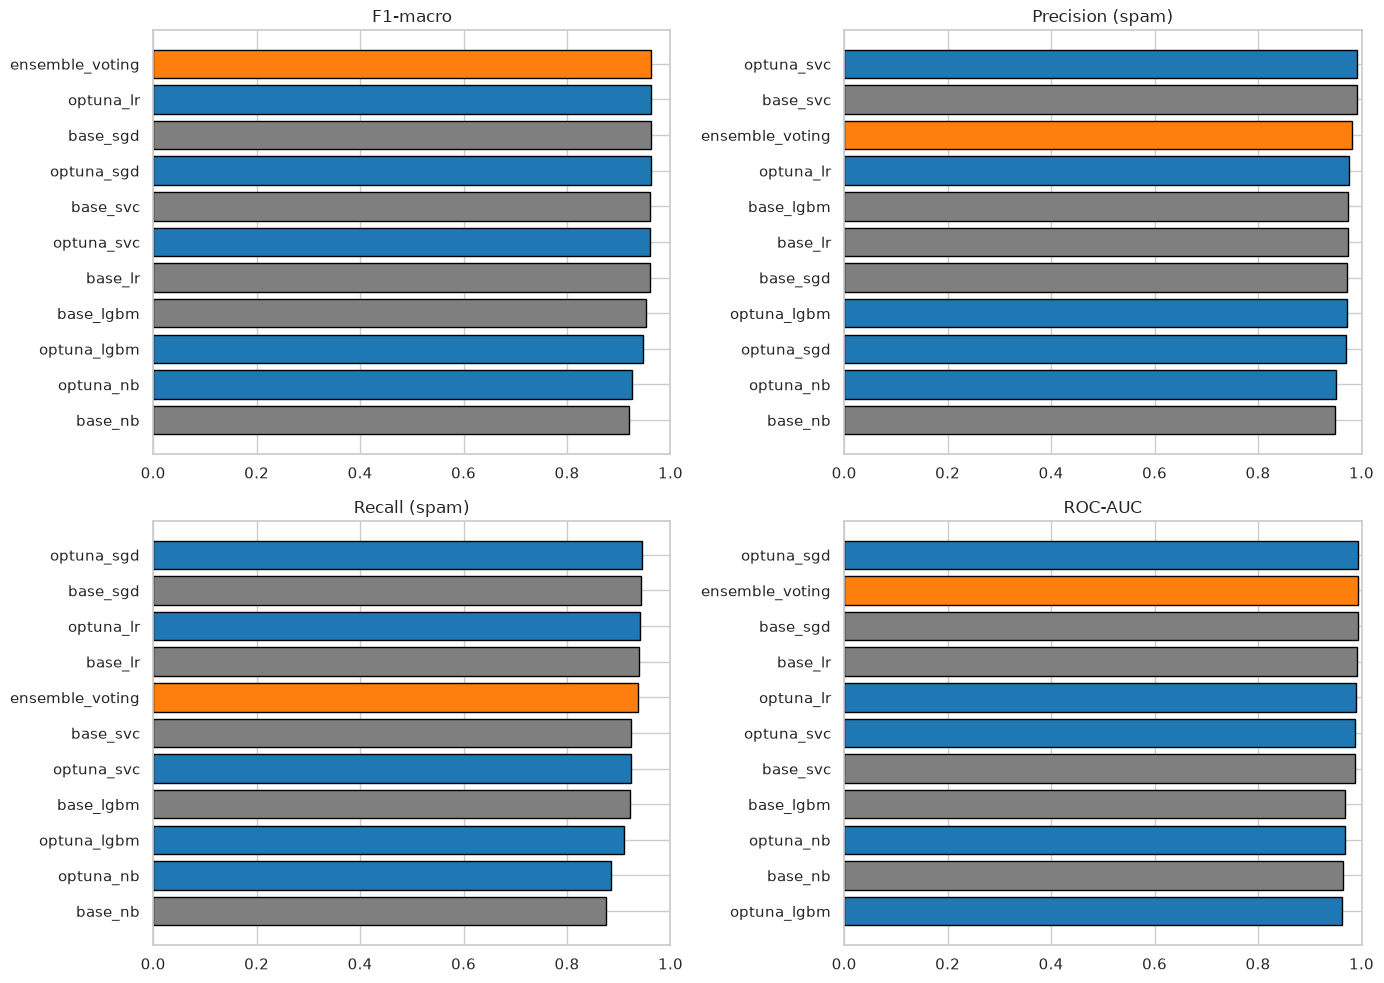

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = [
    ('f1_macro', 'F1-macro', axes[0, 0]),
    ('precision_spam', 'Precision (spam)', axes[0, 1]),
    ('recall_spam', 'Recall (spam)', axes[1, 0]),
    ('roc_auc', 'ROC-AUC', axes[1, 1]),
]

for metric, title, ax in metrics_to_plot:
    data = final_results.sort_values(metric, ascending=True)
    colors = ['tab:blue' if 'optuna' in m else 'tab:orange' if 'ensemble' in m else 'tab:gray'
              for m in data['model']]
    ax.barh(data['model'], data[metric], color=colors, edgecolor='black')
    ax.set_title(title)
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

## Анализ ошибок

Для лучшей модели (по F1-macro) анализируются false positives и false negatives. Выводятся топ-20 примеров каждого типа.

In [14]:
best_model_name = final_results.iloc[0]['model']
print(f'Лучшая модель: {best_model_name}')

if best_model_name.startswith('ensemble_'):
    best_model = ensemble_models[best_model_name.replace('ensemble_', '')]
    y_pred_best = best_model.predict(X_test)
elif best_model_name.startswith('optuna_'):
    key = best_model_name.replace('optuna_', '')
    best_model = optuna_results[key]
    X_eval = X_test_nc if key == 'nb' else X_test
    y_pred_best = best_model.predict(X_eval)
else:
    key = best_model_name.replace('base_', '')
    best_model = base_models[key]
    X_eval = X_test_nc if key == 'nb' else X_test
    y_pred_best = best_model.predict(X_eval)

fp_mask = (y_test_arr == 0) & (y_pred_best == 1)
fn_mask = (y_test_arr == 1) & (y_pred_best == 0)

print(f'False Positives: {fp_mask.sum()}')
print(f'False Negatives: {fn_mask.sum()}')

Лучшая модель: ensemble_voting
False Positives: 336
False Negatives: 1173


Топ-20 false positives (ham, ошибочно помечен как spam).

In [15]:
df_test = pd.read_csv(PROCESSED_DIR / 'test_preprocessed.csv')
df_test = df_test.dropna(subset=['text_preprocessed']).reset_index(drop=True)

fp_indices = np.where(fp_mask)[0][:20]
print('False Positives (ham -> spam):\n')
for idx in fp_indices:
    text = str(df_test.iloc[idx]['text'])[:150]
    print(f'  [{idx}] {text}\n')

False Positives (ham -> spam):

  [83] Благодарю!🙏🙏🙏

  [517] В лс кому?

  [556] Assalomu aleykum aka ,umumiy qancha summa ketarkan  tooshirishga rudnga

  [557] Ha

  [640] Благодарю!

  [752] Здравствуйте! Где увидеть что оплата за обучение прошла?

  [790] 176-859-918 51
s.ss2002@mail.ru 
Алексеева Софья Михайловна 
89774242606
84986491049

  [826] Хочу ремонт показать

  [883] Лучшая компания супердискотеки ❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️❤️

  [884] АЗИЗАА!!!!!🤍🤍🤍🤍

  [1047] Отлично, благодарю за помощь!

  [1135] 4. Возможна ли оплата за несколько лет вперед.

  [1375] Гасымова Нурана Назимовна 89393662727, nunu.gasimova1999@gmail.com

  [1406] Гасымова Нурана Назимовна 
nunu.gasimova1999@gmail.com
89393662727( только нахожусь за границей только через ватс апп доступна)

  [1467] Rudnda oqiysimi

  [1557] Я не могу думать о скидках, глядя на такую красивую девушку 😍💔

  [1583] Проблема решена! Благодарю за помощь!

  [1688] Очень хочу , но у меня работа (((

  [1691] Turke

Топ-20 false negatives (spam, пропущенный моделью).

In [16]:
fn_indices = np.where(fn_mask)[0][:20]
print('False Negatives (spam -> ham):\n')
for idx in fn_indices:
    text = str(df_test.iloc[idx]['text'])[:150]
    print(f'  [{idx}] {text}\n')

False Negatives (spam -> ham):

  [22626] دانیالللل

  [22632] پلن Ps5 چیشد :)

  [22633] اره v2ray

  [22641] جاست pc

  [22649] فهمیدم 2/15 هستی

  [22653] مهو مش شغال pdf

  [22658] معايا 2022

  [22685] هممونو

  [22695] B1 به بالا

  [22706] شب بخیر

  [22711] پشمام imdb 9.2

  [22734] سیو کرده R

  [22735] سیو کردم R🌊☯️

  [22744] المفروض 1.2

  [22756] داش تو ک 210 هی😂😂😂

  [22760] باب رابع 2023

  [22769] شانس مایه 176

  [22774] حضرت عباس

  [22775] 2 تا رزا هست

  [22788] adobe conecet دانلود کن



## Feature Importance

Анализ важности признаков для LightGBM и Logistic Regression. Выводятся топ-20 признаков.

In [17]:
with open(CLASSIC_INTERIM_DIR / 'vectorizers.pkl', 'rb') as f:
    vec_data = pickle.load(f)
vectorizer = vec_data['vectorizer']
char_vectorizer = vec_data['char_vectorizer']

word_names = list(vectorizer.get_feature_names_out())
char_names = list(char_vectorizer.get_feature_names_out()) if char_vectorizer else []
num_names = NUMERICAL_COLUMNS
all_names = word_names + char_names + num_names
print(f'Всего признаков: {len(all_names)}')

Всего признаков: 7020


Feature importance для LightGBM.

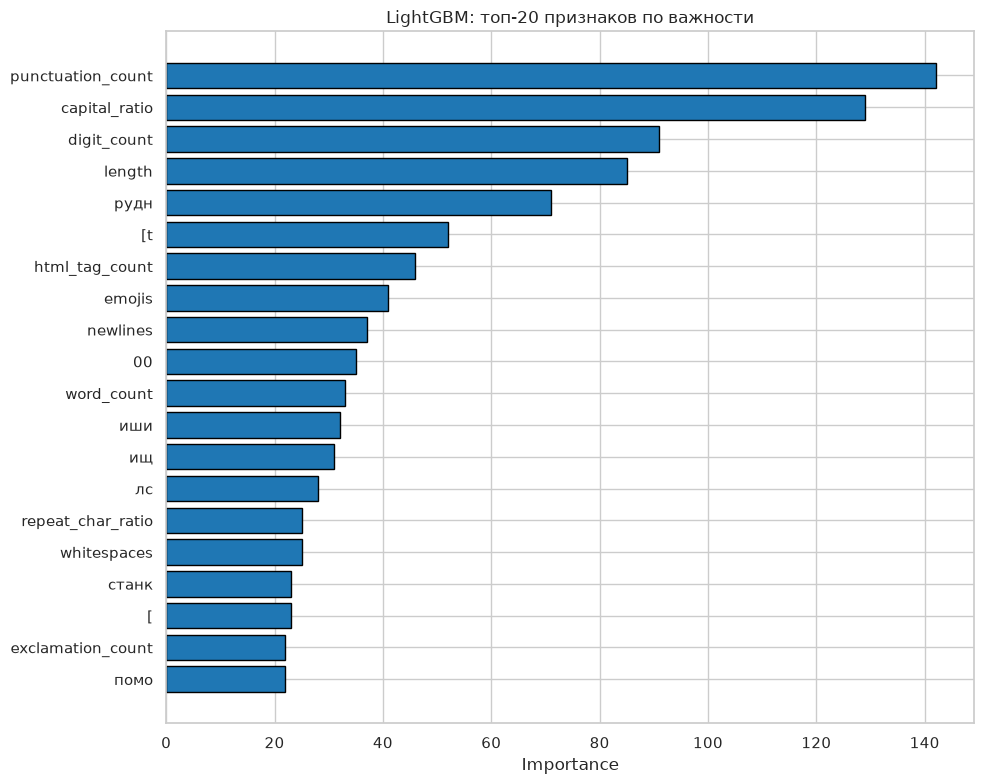

In [18]:
best_lgbm = optuna_results['lgbm']
if hasattr(best_lgbm, 'feature_importances_'):
    importances = best_lgbm.feature_importances_
    top20_idx = np.argsort(importances)[-20:][::-1]
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(
        [all_names[i] if i < len(all_names) else f'feat_{i}' for i in top20_idx][::-1],
        importances[top20_idx][::-1],
        color='tab:blue', edgecolor='black',
    )
    ax.set_title('LightGBM: топ-20 признаков по важности')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()

Коэффициенты Logistic Regression (красный = spam, синий = ham).

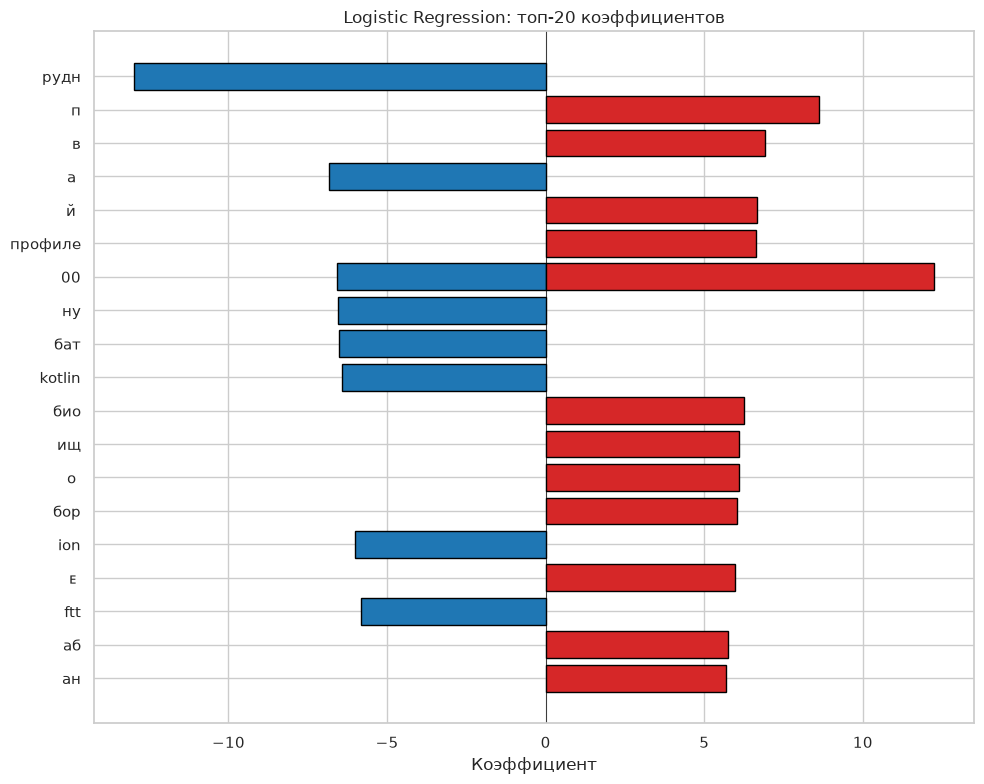

In [19]:
best_lr = optuna_results['lr']
if hasattr(best_lr, 'coef_'):
    coefs = best_lr.coef_[0]
    top20_idx = np.argsort(np.abs(coefs))[-20:][::-1]
    fig, ax = plt.subplots(figsize=(10, 8))
    colors = ['tab:red' if c > 0 else 'tab:blue' for c in coefs[top20_idx]]
    ax.barh(
        [all_names[i] if i < len(all_names) else f'feat_{i}' for i in top20_idx][::-1],
        coefs[top20_idx][::-1],
        color=colors[::-1], edgecolor='black',
    )
    ax.set_title('Logistic Regression: топ-20 коэффициентов')
    ax.set_xlabel('Коэффициент')
    ax.axvline(0, color='black', linewidth=0.5)
    plt.tight_layout()
    plt.show()

## Сохранение результатов и моделей

Итоговая таблица сравнения сохраняется в CSV, модели и векторизаторы — в pickle-файлы.

In [20]:
final_results.to_csv(CLASSIC_INTERIM_DIR / 'classical_baselines_results.csv', index=False)
print(f'Результаты сохранены: {CLASSIC_INTERIM_DIR / "classical_baselines_results.csv"}')
print(f'Строк: {len(final_results)}')

Результаты сохранены: /home/sophrosyne/STANKIN_AntiSpam_Bot/data/interim/classic/classical_baselines_results.csv
Строк: 11


In [21]:
scaler = vec_data['scaler']
save_models(
    optuna_results,
    vectorizer,
    scaler,
    char_vectorizer=char_vectorizer,
    output_dir=CLASSIC_MODELS_DIR,
)
print(f'Модели сохранены в: {CLASSIC_MODELS_DIR}')
print(f'Сохранено файлов: {len(optuna_results)} моделей + vectorizer + scaler + char_vectorizer')

Модели сохранены в: /home/sophrosyne/STANKIN_AntiSpam_Bot/models/classic
Сохранено файлов: 5 моделей + vectorizer + scaler + char_vectorizer


## Демонстрация предсказания на новых сообщениях

In [22]:
example_messages = [
    'Здравствуйте, подскажите пожалуйста сроки поступления',
    'ЗАРАБОТОК В ИНТЕРНЕТЕ!!! Переходи по ссылке и зарабатывай 50000 в день!',
    'Спасибо за информацию',
    'КУПИ ДИПЛОМ ОПТОМ телеграм @diplom_buy',
]

print('Предсказания на примерах:\n')
for text in example_messages:
    pred, proba = predict_message(text, vectorizer, scaler, best_lr, char_vectorizer)
    label = 'SPAM' if pred == 1 else 'HAM'
    print(f'  Текст: {text[:80]}')
    print(f'  Предсказание: {label} (P(spam)={proba[1]:.4f})')
    print()

Предсказания на примерах:

  Текст: Здравствуйте, подскажите пожалуйста сроки поступления
  Предсказание: HAM (P(spam)=0.0010)

  Текст: ЗАРАБОТОК В ИНТЕРНЕТЕ!!! Переходи по ссылке и зарабатывай 50000 в день!
  Предсказание: SPAM (P(spam)=0.9999)

  Текст: Спасибо за информацию
  Предсказание: HAM (P(spam)=0.0059)

  Текст: КУПИ ДИПЛОМ ОПТОМ телеграм @diplom_buy
  Предсказание: SPAM (P(spam)=0.9977)

